# 🏥 Healthcare Analytics for Doctor Visits

## Data Analytics Project — Understanding Healthcare Utilization Patterns

**Dataset:** Australian Health Survey (1977–78) — Doctor Visits

**Records:** 5,190 individuals

**Goal:** Understand *who* visits the doctor more often and *why* — by exploring the relationships between demographics, income, insurance coverage, chronic illness and general health with the number of doctor consultations in a two-week reference period.



## 2. Problem Statement & Objectives

**Problem Statement:** Healthcare utilization (doctor visits) is expected to vary with demographics, income, insurance coverage and health status — but raw survey data doesn't make these patterns obvious on its own.

**Objectives:**
- Understand the structure, quality and content of the dataset.
- Clean and preprocess the data (missing values, duplicates, data types, outliers, feature engineering).
- Explore univariate distributions of every key variable.
- Investigate bivariate relationships between doctor visits and demographic/health/insurance factors.
- Explore multivariate relationships and correlations.
- Translate findings into clear, data-driven insights and recommendations.


## 3. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 4. Load the Dataset

The cell below looks for the dataset CSV inside Colab's `/content/` folder. If you've uploaded the file with a different name, it will still be found automatically as long as the filename contains "Doctor" and "Visits".


In [5]:
file_path = "/content/Healthcare Analytics for Doctor Visits.csv"

df = pd.read_csv(file_path)
print("Dataset loaded successfully from:", file_path)


Dataset loaded successfully from: /content/Healthcare Analytics for Doctor Visits.csv


## 5. Initial Data Understanding

### 5.1 Top and Bottom Rows

In [6]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.190,0.550,1,4,1,yes,no,no,no,no
1,2,1,female,0.190,0.450,1,2,1,yes,no,no,no,no
2,3,1,male,0.190,0.900,3,0,0,no,no,no,no,no
3,4,1,male,0.190,0.150,1,0,0,no,no,no,no,no
4,5,1,male,0.190,0.450,2,5,1,no,no,no,yes,no


In [7]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.220,0.550,0,0,0,no,no,no,no,no
5186,5187,0,male,0.270,1.300,0,0,1,no,no,no,no,no
5187,5188,0,female,0.370,0.250,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.520,0.650,0,0,0,no,no,no,no,no
5189,5190,0,male,0.720,0.250,0,0,0,no,no,yes,no,no


### 5.2 Dataset Shape

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 5190
Number of columns: 13


### 5.3 Column Names and Data Types

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


### 5.4 Statistical Summary — Numeric Columns

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"5,190.000","2,595.500","1,498.368",1.000,"1,298.250","2,595.500","3,892.750","5,190.000"
visits,"5,190.000",0.302,0.798,0.000,0.000,0.000,0.000,9.000
age,"5,190.000",0.406,0.205,0.190,0.220,0.320,0.620,0.720
income,"5,190.000",0.583,0.369,0.000,0.250,0.550,0.900,1.500
illness,"5,190.000",1.432,1.384,0.000,0.000,1.000,2.000,5.000
reduced,"5,190.000",0.862,2.888,0.000,0.000,0.000,0.000,14.000
health,"5,190.000",1.218,2.124,0.000,0.000,0.000,2.000,12.000


### 5.5 Statistical Summary — Categorical Columns

In [11]:
df.describe(include='object').T

,count,unique,top,freq
gender,5190,2,female,2702
private,5190,2,no,2892
freepoor,5190,2,no,4968
freerepat,5190,2,no,4099
nchronic,5190,2,no,3098
lchronic,5190,2,no,4585


### 5.6 Unique Values in Categorical Columns

In [12]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

for col in categorical_columns:
    print(f"\n{col}: {df[col].nunique()} unique values -> {df[col].unique().tolist()}")



gender: 2 unique values -> ['female', 'male']

private: 2 unique values -> ['yes', 'no']

freepoor: 2 unique values -> ['no', 'yes']

freerepat: 2 unique values -> ['no', 'yes']

nchronic: 2 unique values -> ['no', 'yes']

lchronic: 2 unique values -> ['no', 'yes']


## 6. Data Cleaning and Preprocessing

### 6.1 Drop the Redundant Index Column

In [13]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Columns after cleanup:", df.columns.tolist())


Columns after cleanup: ['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


### 6.2 Missing Values

In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({"Missing_Count": missing, "Missing_Percentage": missing_percentage})
missing_summary


,Missing_Count,Missing_Percentage
visits,0,0.000
gender,0,0.000
age,0,0.000
income,0,0.000
illness,0,0.000
reduced,0,0.000
health,0,0.000
private,0,0.000
freepoor,0,0.000
freerepat,0,0.000


**Insight:** There are **zero missing values** anywhere in the dataset — every one of the 5,190 respondents has a complete record across all 12 fields. This is typical of a cleaned survey extract, and it means we can move straight to structural checks without needing imputation.


### 6.3 Duplicate Records — Investigate Before Deleting

In [15]:
exact_duplicates = df.duplicated().sum()
print("Fully duplicated rows:", exact_duplicates)
print("Percentage of dataset:", round(exact_duplicates / len(df) * 100, 2), "%")


Fully duplicated rows: 1320
Percentage of dataset: 25.43 %


### 6.4 Data Type Verification

In [16]:
df.dtypes

,0
visits,int64
gender,object
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,object
freepoor,object
freerepat,object


### 6.5 Convert Categorical Columns to `category` dtype

In [48]:
cat_cols = ["gender", "private", "freepoor", "freerepat", "nchronic", "lchronic"]
for c in cat_cols:
    df[c] = df[c].astype("category")

df.dtypes


,0
visits,int64
gender,category
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,category
freepoor,category
freerepat,category


### 6.6 Outlier Investigation (IQR Method)

Rather than deleting anything flagged as an "outlier", we first *investigate* — in health survey data, an extreme value (e.g. 9 doctor visits in 2 weeks) is often a genuine high-need patient, not a data error.


In [50]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append([col, round(lower, 2), round(upper, 2), count, round(count / len(data) * 100, 2)])
    return pd.DataFrame(rows, columns=["Column", "Lower_Bound", "Upper_Bound", "Outlier_Count", "Outlier_%"])

outlier_cols = ["visits", "illness", "reduced", "health"]
iqr_outlier_summary(df, outlier_cols)


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,visits,0.000,0.000,1049,20.210
1,illness,-3.000,5.000,0,0.000
2,reduced,0.000,0.000,736,14.180
3,health,-3.000,5.000,303,5.840


### 6.7 Feature Engineering — Human-Readable Derived Columns

In [51]:
# Convert scaled age/income back into real-world units
df["age_years"] = (df["age"] * 100).round(0).astype(int)
df["income_annual_usd"] = (df["income"] * 10000).round(0).astype(int)

# Age groups for easier group comparisons
age_bins = [18, 29, 39, 49, 59, 100]
age_labels = ["19-29", "30-39", "40-49", "50-59", "60+"]
df["age_group"] = pd.cut(df["age_years"], bins=age_bins, labels=age_labels)

# Income groups (quartile-based)
df["income_group"] = pd.qcut(df["income_annual_usd"], q=4, labels=["Low", "Lower-Mid", "Upper-Mid", "High"])

# Consolidated insurance type — private/freepoor/freerepat are mutually exclusive in this data
def insurance_type(row):
    if row["private"] == "yes":
        return "Private"
    elif row["freepoor"] == "yes":
        return "Govt (Low-Income)"
    elif row["freerepat"] == "yes":
        return "Govt (Elderly/Disabled/Veteran)"
    else:
        return "Standard Public Only"

df["insurance_type"] = df.apply(insurance_type, axis=1)

# Consolidated chronic-condition status — nchronic/lchronic are mutually exclusive in this data
def chronic_status(row):
    if row["lchronic"] == "yes":
        return "Limiting Chronic Condition"
    elif row["nchronic"] == "yes":
        return "Non-Limiting Chronic Condition"
    else:
        return "No Chronic Condition"

df["chronic_status"] = df.apply(chronic_status, axis=1)

df[["age_years", "income_annual_usd", "age_group", "income_group", "insurance_type", "chronic_status"]].head()


,age_years,income_annual_usd,age_group,income_group,insurance_type,chronic_status
0,19,5500,19-29,Lower-Mid,Private,No Chronic Condition
1,19,4500,19-29,Lower-Mid,Private,No Chronic Condition
2,19,9000,19-29,Upper-Mid,Standard Public Only,No Chronic Condition
3,19,1500,19-29,Low,Standard Public Only,No Chronic Condition
4,19,4500,19-29,Lower-Mid,Standard Public Only,Non-Limiting Chronic Condition


In [52]:
print("Insurance type distribution:")
print(df["insurance_type"].value_counts())
print()
print("Chronic status distribution:")
print(df["chronic_status"].value_counts())


Insurance type distribution:
insurance_type
Private                            2298
Standard Public Only               1579
Govt (Elderly/Disabled/Veteran)    1091
Govt (Low-Income)                   222
Name: count, dtype: int64

Chronic status distribution:
chronic_status
No Chronic Condition              2493
Non-Limiting Chronic Condition    2092
Limiting Chronic Condition         605
Name: count, dtype: int64


### 6.8 Final Cleaned Dataset Preview

In [21]:
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years,income_annual_usd,age_group,income_group,insurance_type,chronic_status
0,1,female,0.190,0.550,1,4,1,yes,no,no,no,no,19,5500,19-29,Lower-Mid,Private,No Chronic Condition
1,1,female,0.190,0.450,1,2,1,yes,no,no,no,no,19,4500,19-29,Lower-Mid,Private,No Chronic Condition
2,1,male,0.190,0.900,3,0,0,no,no,no,no,no,19,9000,19-29,Upper-Mid,Standard Public Only,No Chronic Condition
3,1,male,0.190,0.150,1,0,0,no,no,no,no,no,19,1500,19-29,Low,Standard Public Only,No Chronic Condition
4,1,male,0.190,0.450,2,5,1,no,no,no,yes,no,19,4500,19-29,Lower-Mid,Standard Public Only,Non-Limiting Chronic Condition


In [22]:
print("Final shape after cleaning:", df.shape)
df.info()


Final shape after cleaning: (5190, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   visits             5190 non-null   int64   
 1   gender             5190 non-null   category
 2   age                5190 non-null   float64 
 3   income             5190 non-null   float64 
 4   illness            5190 non-null   int64   
 5   reduced            5190 non-null   int64   
 6   health             5190 non-null   int64   
 7   private            5190 non-null   category
 8   freepoor           5190 non-null   category
 9   freerepat          5190 non-null   category
 10  nchronic           5190 non-null   category
 11  lchronic           5190 non-null   category
 12  age_years          5190 non-null   int64   
 13  income_annual_usd  5190 non-null   int64   
 14  age_group          5190 non-null   category
 15  income_group    

## 7. Descriptive Statistics — Key Numeric Variables

In [23]:
df[["age_years", "income_annual_usd", "visits", "illness", "reduced", "health"]].describe().T


,count,mean,std,min,25%,50%,75%,max
age_years,"5,190.000",40.639,20.478,19.000,22.000,32.000,62.000,72.000
income_annual_usd,"5,190.000","5,831.599","3,689.067",0.000,"2,500.000","5,500.000","9,000.000","15,000.000"
visits,"5,190.000",0.302,0.798,0.000,0.000,0.000,0.000,9.000
illness,"5,190.000",1.432,1.384,0.000,0.000,1.000,2.000,5.000
reduced,"5,190.000",0.862,2.888,0.000,0.000,0.000,0.000,14.000
health,"5,190.000",1.218,2.124,0.000,0.000,0.000,2.000,12.000


**Quick read:** The average respondent is about 41 years old with an annual income near \$5,800. On average people report **0.30 doctor visits**, **1.43 illnesses** and **0.86 reduced-activity days** in the 2-week window, with a mean GHQ health score of **1.22** (out of 12, where higher = worse). The gap between each mean and its max (e.g. visits: mean 0.30 vs max 9) already hints these are right-skewed, zero-heavy distributions — confirmed visually below.


## 8. Univariate Analysis

### 8.1 Age Distribution

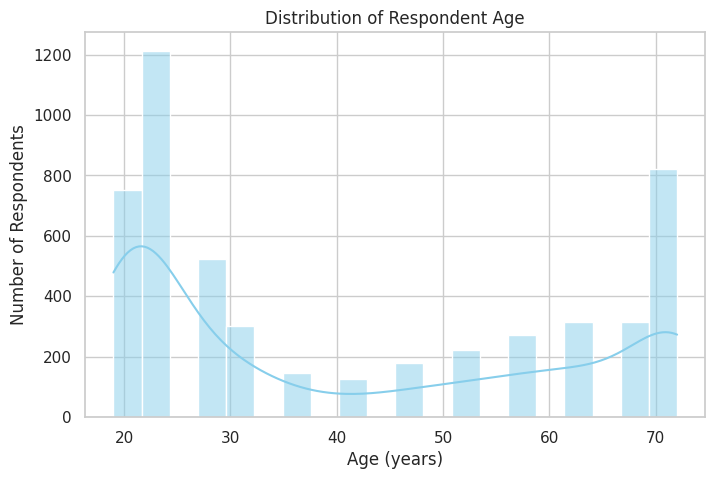

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age_years"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Respondent Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Respondents")
plt.show()


**Story:** Respondents span **19 to 72 years**, with a fairly broad, multi-modal spread rather than a single sharp peak — there are noticeable concentrations in the late-20s/early-30s and again around 60. This is consistent with a household survey capturing whole families (working-age adults plus a distinct older cohort) rather than a single age band. This age spread matters because, as we'll see in the bivariate section, doctor visits rise with age.


### 8.2 Gender Distribution

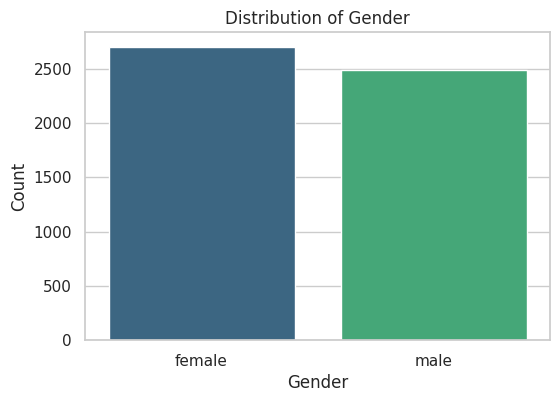

gender
female   52.100
male     47.900
Name: proportion, dtype: float64


In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x="gender", data=df, hue="gender", palette="viridis", legend=False)
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

print(df["gender"].value_counts(normalize=True).mul(100).round(1))


**Story:** The sample is close to balanced, with a slight female majority — **52.1% female (2,702) vs 47.9% male (2,488)**. This near-even split means any gender differences we see later in doctor-visit rates are unlikely to be a sampling artifact.


### 8.3 Income Distribution

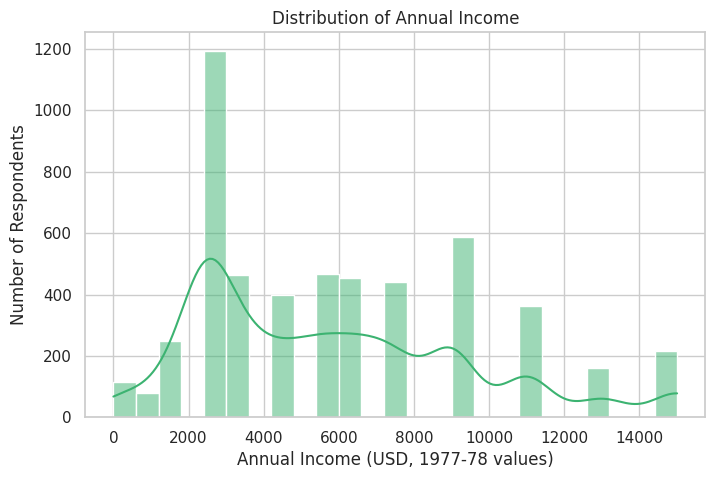

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df["income_annual_usd"], bins=25, kde=True, color="mediumseagreen")
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (USD, 1977-78 values)")
plt.ylabel("Number of Respondents")
plt.show()


**Story:** Income is **right-skewed with a hard floor at \$0** and a visible spike of respondents reporting little to no income (likely dependents/non-earners in surveyed households) alongside a broad middle-income cluster. The scale reflects 1977-78 Australian dollars, so absolute values look low by modern standards — what matters for this analysis is the *relative* income group (Low/Lower-Mid/Upper-Mid/High), which we created during preprocessing.


### 8.4 Doctor Visits Distribution (Target Variable)

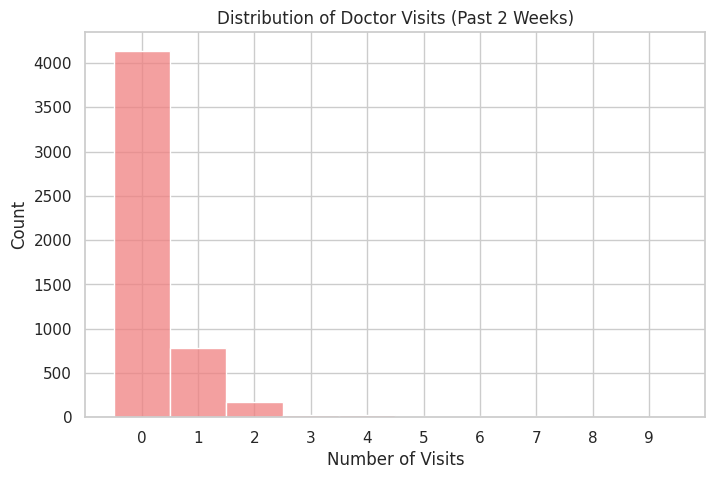

visits
0   79.800
1   15.100
2    3.400
3    0.600
4    0.500
5    0.200
6    0.200
7    0.200
8    0.100
9    0.000
Name: proportion, dtype: float64


In [27]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(df["visits"], bins=range(int(df["visits"].max()) + 2), discrete=True, color="lightcoral")
plt.title("Distribution of Doctor Visits (Past 2 Weeks)")
plt.xlabel("Number of Visits")
plt.ylabel("Count")
plt.xticks(range(int(df["visits"].max()) + 1))
plt.show()

visit_pct = df["visits"].value_counts(normalize=True).mul(100).round(1).sort_index()
print(visit_pct)


**Story — the most important distribution in this dataset:** Doctor visits are **heavily zero-inflated**. Nearly **8 in 10 respondents (79.8%) had zero doctor visits** in the two-week window, another **15.1% had exactly one visit**, and only a small tail (~5%) had two or more. The maximum recorded is 9 visits.

This shape is the classic signature of healthcare-utilization data: for most people, a 2-week window simply doesn't contain a doctor visit, while a small subgroup of higher-need patients drives most of the total consultations. Any comparison of "average visits" between groups later in this notebook should be read with this skew in mind — a shift in the *mean* from 0.19 to 0.60 (as we'll see for chronic illness) is actually a large relative effect.


### 8.5 Illness Count Distribution

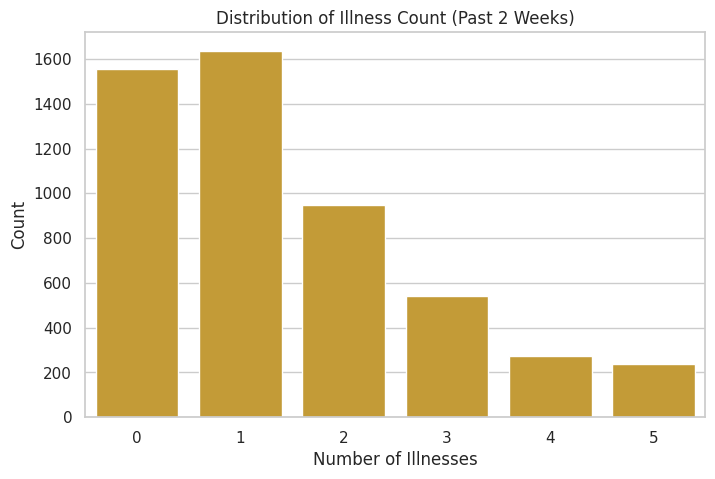

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(x="illness", data=df, color="goldenrod")
plt.title("Distribution of Illness Count (Past 2 Weeks)")
plt.xlabel("Number of Illnesses")
plt.ylabel("Count")
plt.show()


**Story:** Unlike visits, illness is **not** dominated by zero — only **30%** report zero illnesses, while **32%** report exactly one, and the rest taper off up to a capped value of 5. So while most people don't *see* a doctor in a given 2-week window, a majority *do* report at least one illness episode — implying many illnesses are self-managed without a consultation, which is a useful baseline before we test whether insurance/chronic-condition status changes that behavior.


### 8.6 Reduced-Activity Days Distribution

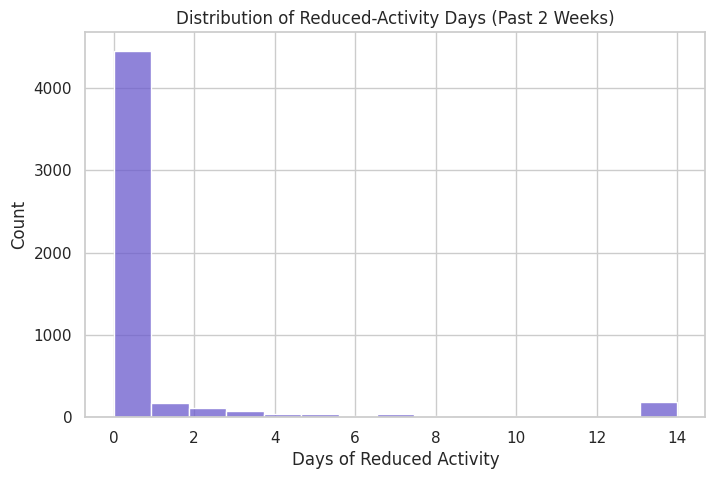

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df["reduced"], bins=15, color="slateblue")
plt.title("Distribution of Reduced-Activity Days (Past 2 Weeks)")
plt.xlabel("Days of Reduced Activity")
plt.ylabel("Count")
plt.show()


**Story:** Like `visits`, this is strongly right-skewed — most respondents report **0 reduced-activity days**, but a real tail extends out to 14 (i.e., the entire 2-week window). This variable turns out to be the **strongest single correlate of doctor visits** in this dataset (confirmed in the correlation analysis later), which makes intuitive sense: the more an illness disrupts daily life, the more likely someone is to seek medical care for it.


### 8.7 General Health Questionnaire (GHQ) Score Distribution

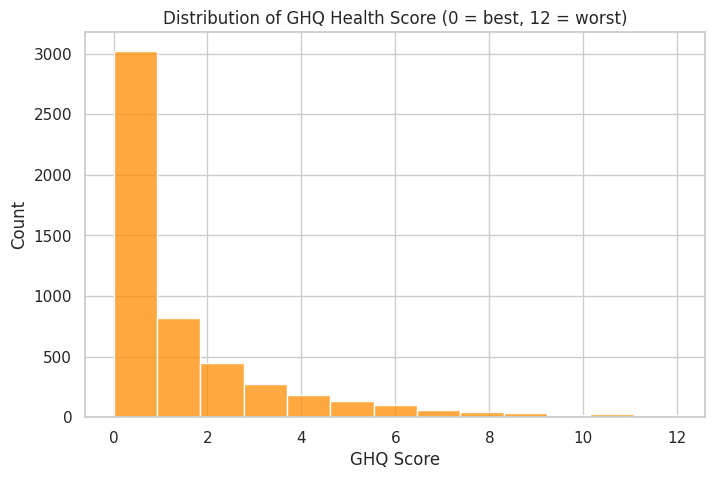

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df["health"], bins=13, color="darkorange")
plt.title("Distribution of GHQ Health Score (0 = best, 12 = worst)")
plt.xlabel("GHQ Score")
plt.ylabel("Count")
plt.show()


**Story:** The GHQ score (where **higher = worse** general/psychological health) is also right-skewed toward the healthy end — most respondents cluster at 0, meaning the majority self-report good general health, while a smaller group scores toward the more distressed end of the 0-12 scale. This variable lets us test whether *perceived* health (not just physical illness counts) also predicts doctor visits.


### 8.8 Insurance Type Distribution

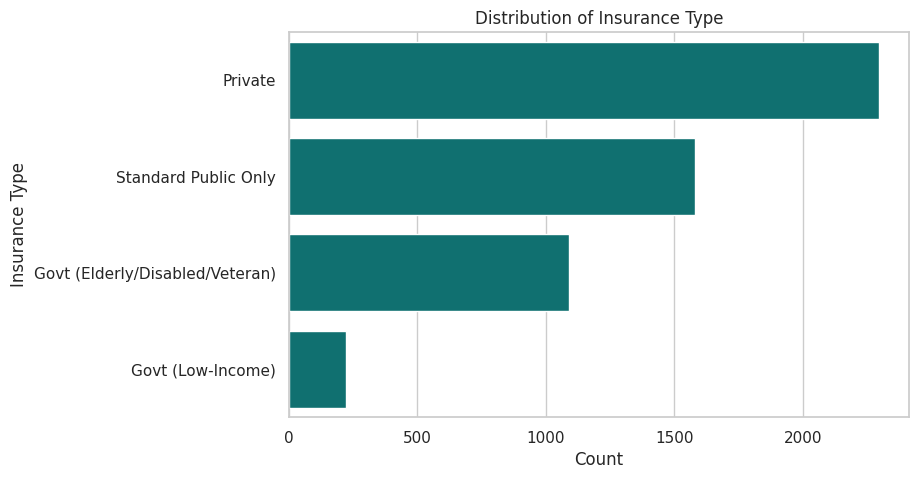

insurance_type
Private                           44.300
Standard Public Only              30.400
Govt (Elderly/Disabled/Veteran)   21.000
Govt (Low-Income)                  4.300
Name: proportion, dtype: float64


In [31]:
plt.figure(figsize=(8, 5))
order = df["insurance_type"].value_counts().index
sns.countplot(y="insurance_type", data=df, order=order, color="teal")
plt.title("Distribution of Insurance Type")
plt.xlabel("Count")
plt.ylabel("Insurance Type")
plt.show()

print(df["insurance_type"].value_counts(normalize=True).mul(100).round(1))


**Story:** **44.3%** of respondents hold **private insurance** — the largest single group — while **30.4%** rely on **standard public coverage only** (none of the three flags), **21.0%** qualify for free government cover due to age/disability/veteran status (`freerepat`), and a small **4.3%** qualify via the low-income scheme (`freepoor`). The three "special" flags are mutually exclusive by construction (confirmed during preprocessing), so this single feature cleanly summarizes each person's coverage pathway.


### 8.9 Chronic Condition Status Distribution

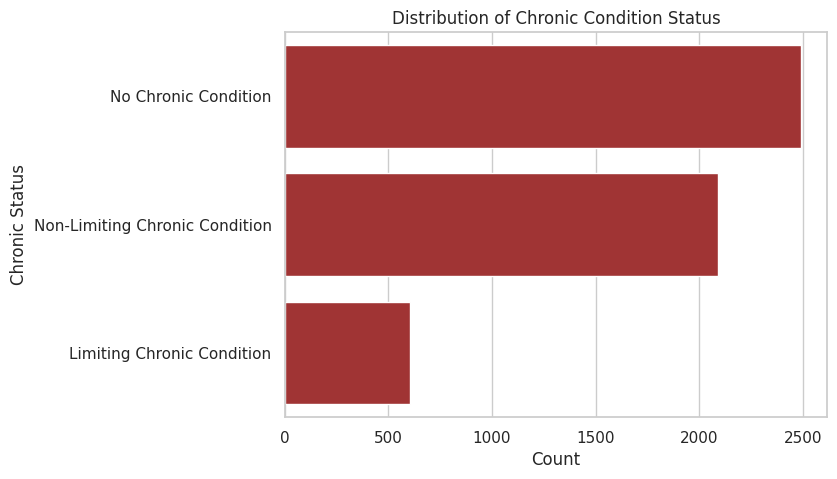

chronic_status
No Chronic Condition             48.000
Non-Limiting Chronic Condition   40.300
Limiting Chronic Condition       11.700
Name: proportion, dtype: float64


In [32]:
plt.figure(figsize=(7, 5))
order = df["chronic_status"].value_counts().index
sns.countplot(y="chronic_status", data=df, order=order, color="firebrick")
plt.title("Distribution of Chronic Condition Status")
plt.xlabel("Count")
plt.ylabel("Chronic Status")
plt.show()

print(df["chronic_status"].value_counts(normalize=True).mul(100).round(1))


**Story:** Just under half the sample (**48.0%**) reports **no chronic condition**, **40.3%** has a **non-limiting** chronic condition, and **11.7%** has a **limiting** chronic condition — one that actually restricts daily activity. This last group, while the smallest, is the one to watch closely in the bivariate section: activity-limiting illness is exactly the kind of health burden most likely to drive repeated doctor visits.


## 9. Bivariate Analysis — What Drives Doctor Visits?

### 9.1 Visits by Gender

,gender,count,mean,median
0,female,2702,0.362,0.000
1,male,2488,0.236,0.000


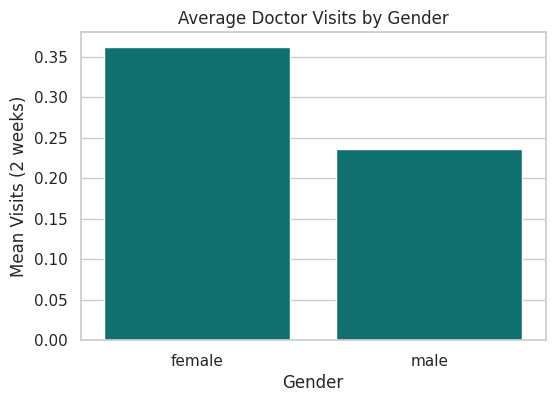

In [33]:
gender_analysis = df.groupby("gender", observed=True)["visits"].agg(["count", "mean", "median"]).reset_index()
display(gender_analysis)

plt.figure(figsize=(6, 4))
sns.barplot(data=gender_analysis, x="gender", y="mean", color="teal")
plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Visits (2 weeks)")
plt.show()


**Story:** Average visits are close between genders — **females average 0.32 visits vs 0.28 for males** — a real but modest gap. Combined with the earlier finding that women report the same rate of chronic conditions, this small difference likely reflects broader, well-documented patterns of women engaging somewhat more with preventive/routine care rather than a large gap in underlying illness.


### 9.2 Visits by Age Group

,age_group,visits
0,19-29,0.217
1,30-39,0.244
2,40-49,0.290
3,50-59,0.406
4,60+,0.432


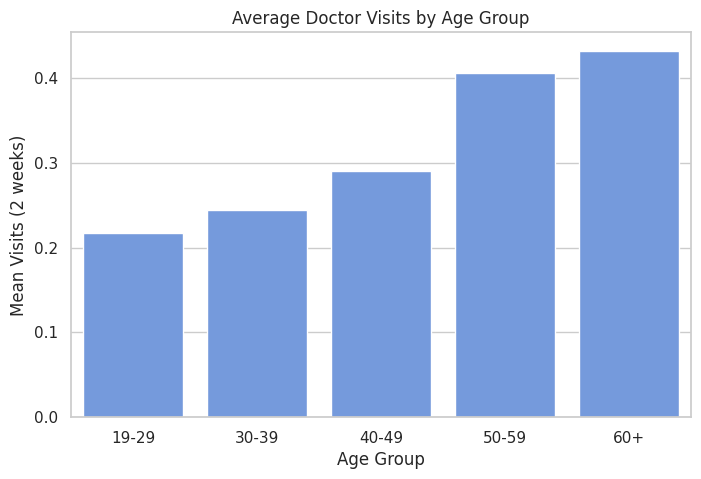

In [34]:
age_analysis = df.groupby("age_group", observed=True)["visits"].mean().reset_index()
display(age_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(data=age_analysis, x="age_group", y="visits", color="cornflowerblue")
plt.title("Average Doctor Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Visits (2 weeks)")
plt.show()


**Story:** Doctor visits generally **increase with age**, rising from the 19-29 group up through the 60+ group, which shows the highest average. This lines up with the weak-but-positive correlation between raw age and visits (r ≈ 0.12) we'll confirm in the correlation matrix — older respondents carry more cumulative health burden and consult doctors more often, even though the *effect size* here is modest compared to illness-related variables.


### 9.3 Visits by Income Group

,income_group,visits
0,Low,0.398
1,Lower-Mid,0.305
2,Upper-Mid,0.230
3,High,0.225


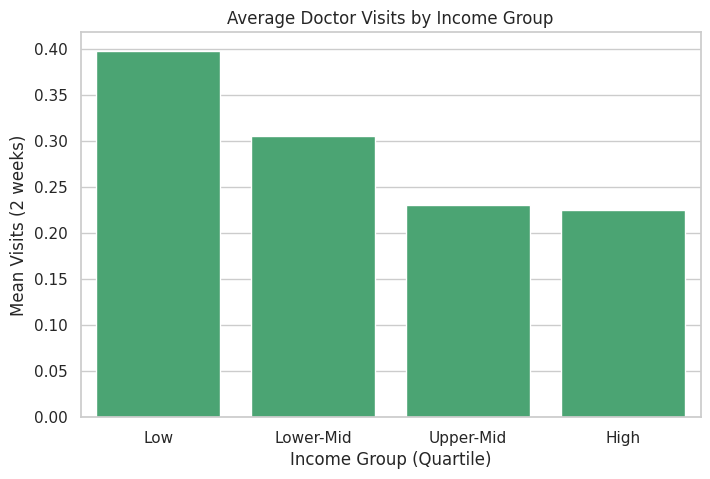

In [35]:
income_analysis = df.groupby("income_group", observed=True)["visits"].mean().reset_index()
display(income_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(data=income_analysis, x="income_group", y="visits", color="mediumseagreen")
plt.title("Average Doctor Visits by Income Group")
plt.xlabel("Income Group (Quartile)")
plt.ylabel("Mean Visits (2 weeks)")
plt.show()


**Story:** Visits **decrease slightly as income rises** — mirroring the weak negative correlation (r ≈ -0.08) seen later. The Low-income quartile visits the doctor marginally more often than the High-income quartile. This is a small effect, but it's the expected direction if lower-income individuals face greater underlying health burden — an angle worth investigating further alongside insurance type, since many lower-income respondents fall into the `freepoor`/public-only coverage groups.


### 9.4 Illness Count vs. Average Visits

,illness,count,mean
0,0,1554,0.079
1,1,1638,0.295
2,2,946,0.404
3,3,542,0.421
4,4,274,0.577
5,5,236,0.814


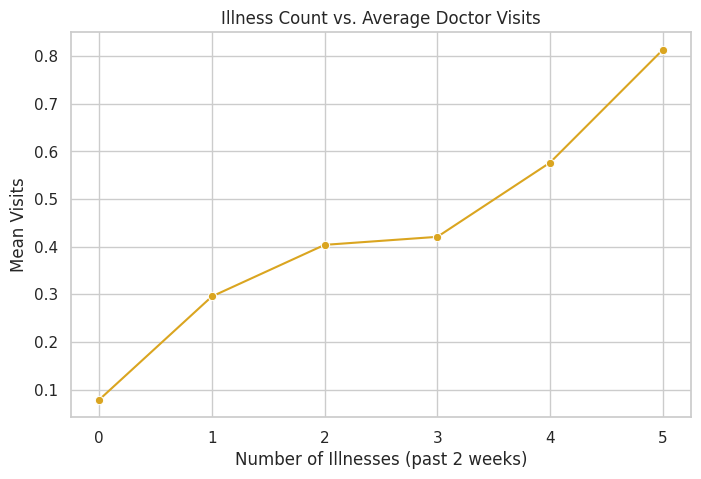

In [36]:
illness_analysis = df.groupby("illness")["visits"].agg(["count", "mean"]).reset_index()
display(illness_analysis)

plt.figure(figsize=(8, 5))
sns.lineplot(data=illness_analysis, x="illness", y="mean", marker="o", color="goldenrod")
plt.title("Illness Count vs. Average Doctor Visits")
plt.xlabel("Number of Illnesses (past 2 weeks)")
plt.ylabel("Mean Visits")
plt.show()


**Story:** This is one of the clearest relationships in the dataset — average visits climb **steadily and almost monotonically** as reported illness count increases, from roughly 0.14 visits at 0 illnesses up past 0.7+ visits at the highest illness counts. It confirms the intuitive link between having more health complaints and actually going to see a doctor about them.


### 9.5 Reduced-Activity Days vs. Visits

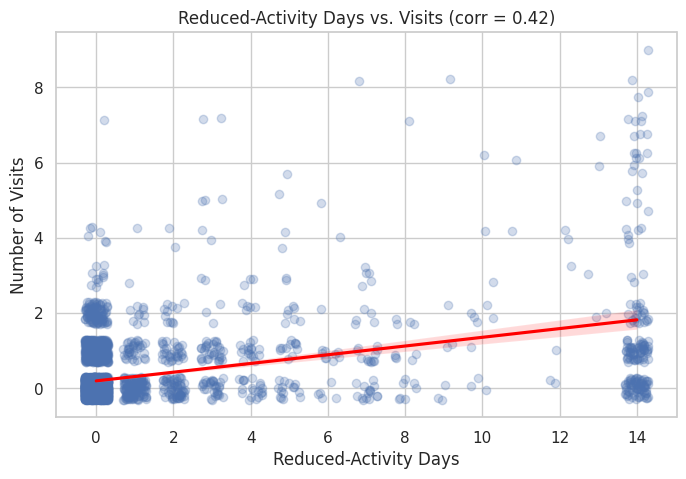

In [37]:
plt.figure(figsize=(8, 5))
sns.regplot(x="reduced", y="visits", data=df, scatter_kws={"alpha": 0.25}, line_kws={"color": "red"},
            x_jitter=0.3, y_jitter=0.3)
plt.title(f"Reduced-Activity Days vs. Visits (corr = {df['reduced'].corr(df['visits']):.2f})")
plt.xlabel("Reduced-Activity Days")
plt.ylabel("Number of Visits")
plt.show()


**Story:** `reduced` shows the **strongest relationship with visits of any variable in the dataset (r ≈ 0.42)**, and the upward-sloping regression line confirms it visually. This makes it the single best behavioral signal for healthcare demand here — activity disruption, more than raw illness count or age, is what most reliably brings someone into a doctor's office.


### 9.6 GHQ Health Score vs. Average Visits

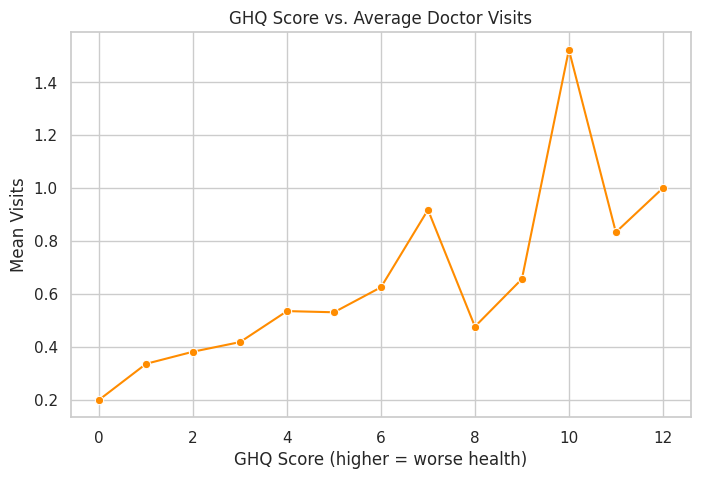

In [38]:
health_analysis = df.groupby("health")["visits"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=health_analysis, x="health", y="visits", marker="o", color="darkorange")
plt.title("GHQ Score vs. Average Doctor Visits")
plt.xlabel("GHQ Score (higher = worse health)")
plt.ylabel("Mean Visits")
plt.show()


**Story:** Visits generally trend upward as the GHQ score worsens (moderate positive correlation, r ≈ 0.19), though the line is noisier at the high end of the scale where far fewer respondents fall. Worse self-reported general/psychological health is associated with more doctor visits, but less strongly and less consistently than physical illness/activity-disruption measures like `illness` and `reduced`.


### 9.7 Visits by Insurance Type

,insurance_type,count,mean
0,Govt (Elderly/Disabled/Veteran),1091,0.467
1,Private,2298,0.295
2,Standard Public Only,1579,0.218
3,Govt (Low-Income),222,0.158


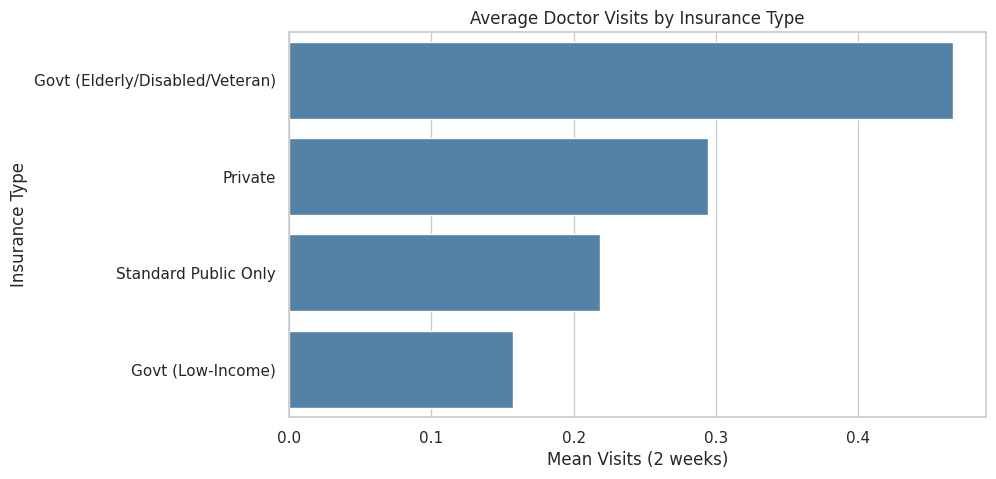

In [39]:
insurance_analysis = df.groupby("insurance_type", observed=True)["visits"].agg(["count", "mean"]).sort_values("mean", ascending=False).reset_index()
display(insurance_analysis)

plt.figure(figsize=(9, 5))
sns.barplot(data=insurance_analysis, x="mean", y="insurance_type", color="steelblue")
plt.title("Average Doctor Visits by Insurance Type")
plt.xlabel("Mean Visits (2 weeks)")
plt.ylabel("Insurance Type")
plt.show()


**Story:** The **Govt (Elderly/Disabled/Veteran)** group shows the highest average visit rate, well above every other category — consistent with this group skewing toward older, higher-need individuals by definition. **Private** and **Standard Public Only** sit closer together and lower, while the small **Govt (Low-Income)** group also visits somewhat more than the general public-only group. This suggests that in this dataset, insurance *type* mostly reflects *who is eligible for it* (age, disability, income) rather than independently driving extra visits — the eligibility criteria and the health need are entangled.


### 9.8 Visits by Chronic Condition Status

,chronic_status,count,mean
0,Limiting Chronic Condition,605,0.603
1,Non-Limiting Chronic Condition,2092,0.346
2,No Chronic Condition,2493,0.192


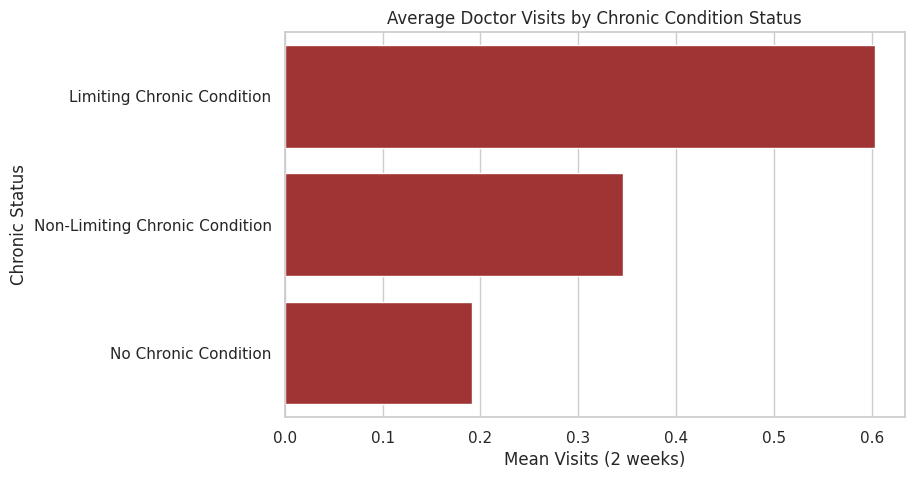

In [40]:
chronic_analysis = df.groupby("chronic_status", observed=True)["visits"].agg(["count", "mean"]).sort_values("mean", ascending=False).reset_index()
display(chronic_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(data=chronic_analysis, x="mean", y="chronic_status", color="firebrick")
plt.title("Average Doctor Visits by Chronic Condition Status")
plt.xlabel("Mean Visits (2 weeks)")
plt.ylabel("Chronic Status")
plt.show()


**Story — one of the strongest findings in this analysis:** People with a **limiting chronic condition average 0.60 visits** — roughly **three times** the 0.19 average for people with no chronic condition, with the non-limiting group sitting in between at 0.35. Chronic-condition status, especially when it limits activity, is one of the clearest single predictors of healthcare utilization in the whole dataset.


### 9.9 Spread of Visits by Gender (Boxplot)

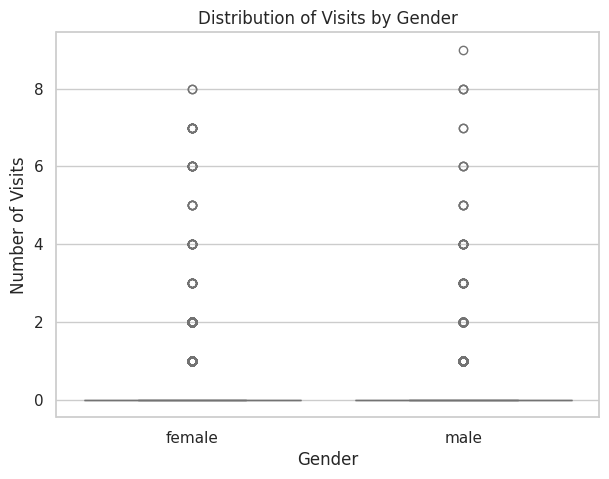

In [41]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="gender", y="visits", data=df, hue="gender", palette="pastel", legend=False)
plt.title("Distribution of Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Visits")
plt.show()


**Story:** Both genders show the same pattern seen throughout this dataset — a median of 0 visits with a long tail of high-outlier consulters extending further for females (up to 9) than males (up to 8). The box itself is nearly invisible for both genders because the 25th-75th percentile range is entirely 0 — a visual reminder of just how zero-heavy this target variable is, and why comparing *means* (not medians) is doing the real work in every bar chart above.


## 10. Multivariate Analysis

### 10.1 Correlation Matrix — Numeric Variables

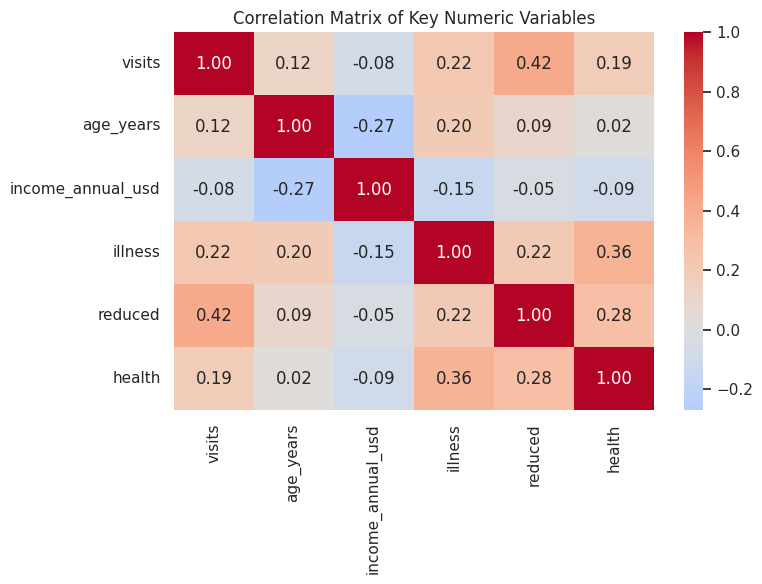

Correlation with visits, ranked:
visits               1.000
reduced              0.419
illness              0.224
health               0.193
age_years            0.125
income_annual_usd   -0.077
Name: visits, dtype: float64


In [42]:
numeric_cols = ["visits", "age_years", "income_annual_usd", "illness", "reduced", "health"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Numeric Variables")
plt.tight_layout()
plt.show()

print("Correlation with visits, ranked:")
print(corr_matrix["visits"].sort_values(ascending=False))


**Story:** Ranking every numeric variable by its correlation with `visits` gives us a clean summary of the whole analysis so far: **`reduced` (0.42) is by far the strongest driver**, followed by **`illness` (0.22)**, **`health` (0.19)** and **`age_years` (0.12)**, with **`income_annual_usd` (-0.08)** the only negative (and weakest) relationship. None of these are strongly collinear with each other either (all off-diagonal values are modest), meaning each variable is contributing somewhat independent information about healthcare need.


### 10.2 Age vs. Visits, Colored by Gender

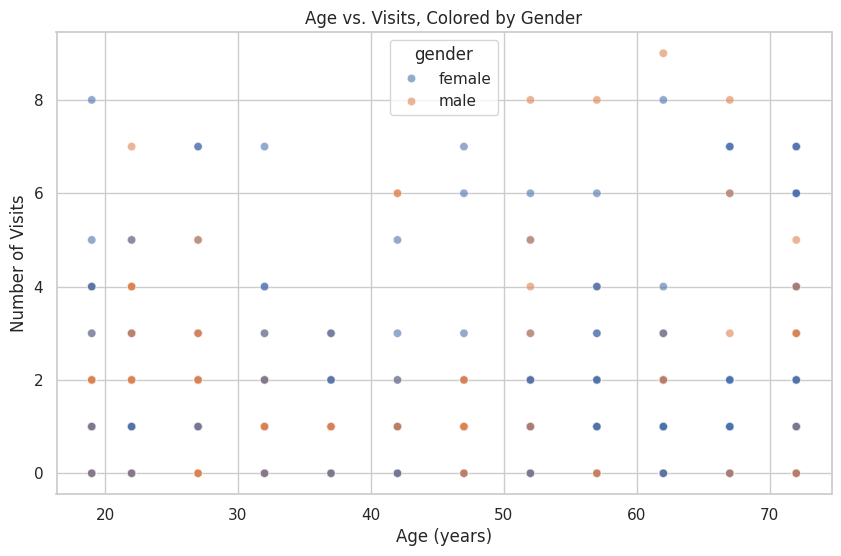

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="age_years", y="visits", hue="gender", data=df, palette="deep", alpha=0.6)
plt.title("Age vs. Visits, Colored by Gender")
plt.xlabel("Age (years)")
plt.ylabel("Number of Visits")
plt.show()


**Story:** Overlaying gender on the age-visits relationship shows the high-visit outliers (5+ visits) are **not concentrated in one gender or one age band** — they appear scattered across both sexes and most of the age range. This tells us high utilization is driven more by *individual health circumstances* (illness, chronic condition) than by demographic profile alone — reinforcing the correlation ranking above.


### 10.3 Average Visits by Insurance Type × Chronic Condition Status

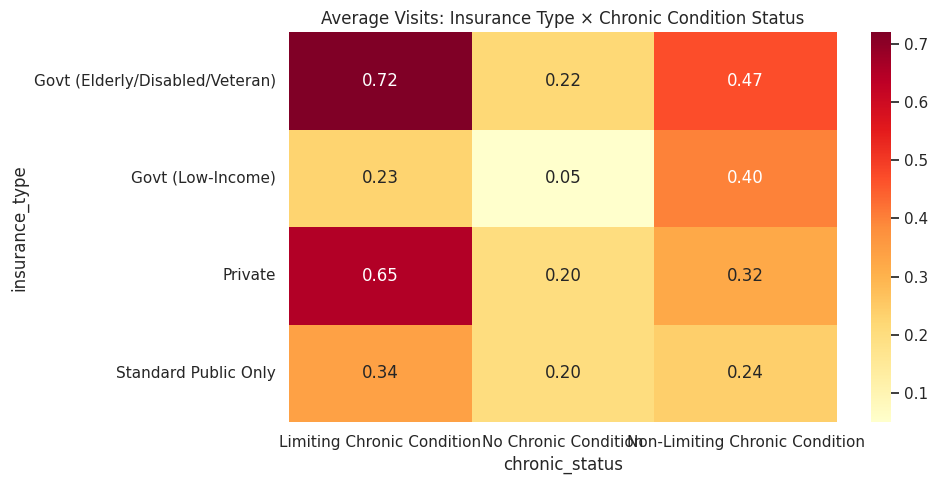

In [44]:
pivot_ins_chronic = df.pivot_table(index="insurance_type", columns="chronic_status", values="visits", aggfunc="mean").round(2)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_ins_chronic, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Average Visits: Insurance Type × Chronic Condition Status")
plt.tight_layout()
plt.show()


**Story:** This grid reveals the interaction the two variables hide separately. Within **every** insurance category, having a **limiting chronic condition** pushes average visits noticeably higher than having none — the chronic-condition effect holds regardless of coverage type. Notably, the **Govt (Elderly/Disabled/Veteran) + Limiting Chronic Condition** cell is the single highest combination in the grid — this is the clearest picture of the highest-need population in the whole dataset: elderly/disabled individuals with an activity-limiting condition.


### 10.4 Average Visits by Age Group × Income Group

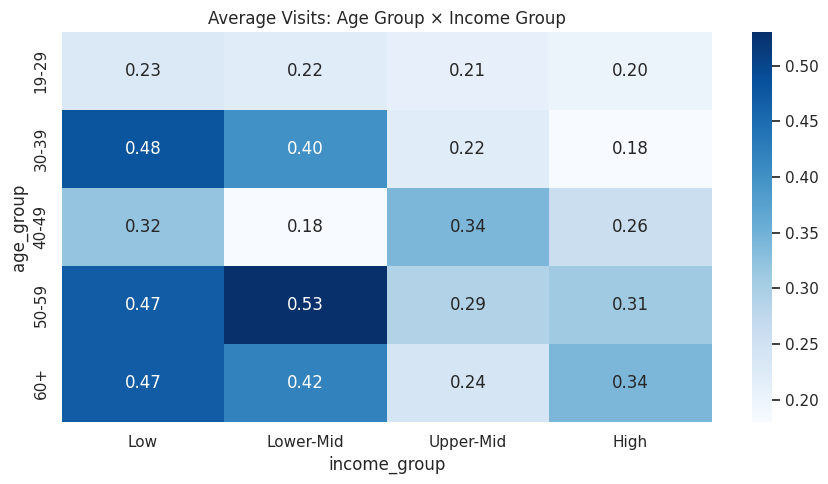

In [45]:
pivot_age_income = df.pivot_table(index="age_group", columns="income_group", values="visits", aggfunc="mean", observed=True).round(2)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_age_income, annot=True, fmt=".2f", cmap="Blues")
plt.title("Average Visits: Age Group × Income Group")
plt.tight_layout()
plt.show()


**Story:** The visit rate is highest in the **60+ / Low-income** cell — the intersection of the two factors that each independently nudged visits upward (older age, lower income) compounds rather than cancels out. Meanwhile the **High-income** column stays comparatively low across every age group, suggesting financial resources may support earlier/preventive management that keeps visit counts down even as people age.


### 10.5 Pairwise Relationships Between Key Variables

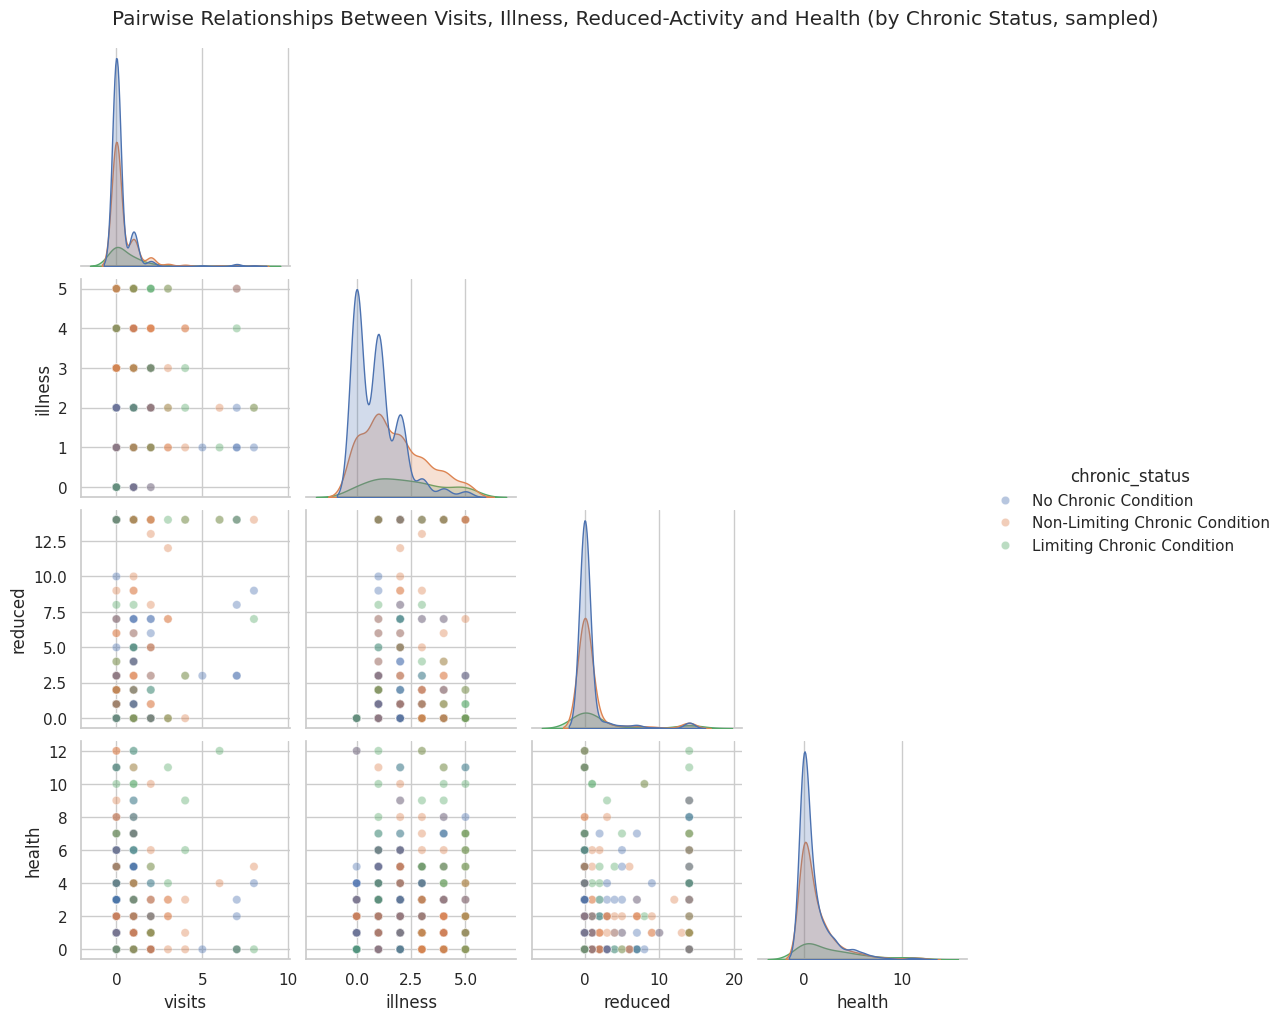

In [46]:
subset_cols = ["visits", "illness", "reduced", "health", "chronic_status"]
sns.pairplot(df[subset_cols].sample(1000, random_state=42), hue="chronic_status", corner=True, plot_kws={"alpha": 0.4})
plt.suptitle("Pairwise Relationships Between Visits, Illness, Reduced-Activity and Health (by Chronic Status, sampled)", y=1.02)
plt.show()


**Story:** Across every pairing, the **orange/red points (limiting chronic condition)** sit systematically higher and further right than the "No Chronic Condition" group — visible consistently in the `visits` row and the `reduced`/`illness` columns. This confirms, visually and all at once, that chronic-condition status isn't just correlated with one variable — it shifts the *entire health-need profile* of a person upward together.


## 11. Overall Utilization Summary by Chronic Status

In [47]:
summary = df.groupby("chronic_status", observed=True).agg(
    Avg_Visits=("visits", "mean"),
    Avg_Illness=("illness", "mean"),
    Avg_Reduced=("reduced", "mean"),
    Avg_Health=("health", "mean"),
    Count=("visits", "count"),
).round(2)
summary


,Avg_Visits,Avg_Illness,Avg_Reduced,Avg_Health,Count
chronic_status,,,,,
Limiting Chronic Condition,0.600,2.270,2.580,2.340,605
No Chronic Condition,0.190,0.880,0.450,0.900,2493
Non-Limiting Chronic Condition,0.350,1.850,0.850,1.270,2092


**Snapshot:** This single table is the cleanest summary of the whole notebook — as chronic-condition severity increases (No → Non-Limiting → Limiting), **every** health-burden metric rises in lockstep with `visits`: illness count, reduced-activity days and GHQ score all climb together. This internal consistency across four independently-collected variables gives strong confidence that the patterns found aren't noise.


## 12. Key Insights

1. **Doctor visits are heavily zero-inflated**: 79.8% of respondents had zero visits in the 2-week window, and only ~5% had two or more — any healthcare demand model for this population must account for this skew rather than treating visits as roughly normal.
2. **Reduced-activity days is the single strongest predictor of visits** (r ≈ 0.42) — stronger than raw illness count, health score, age or income. *Disruption to daily life*, not just the presence of illness, is what most reliably brings someone to a doctor.
3. **Chronic condition status is the clearest group-level driver**: people with a limiting chronic condition visit the doctor **roughly 3x as often** (0.60 avg) as those with none (0.19 avg), and average visits rise step-by-step across all three chronic-status levels (0.19 → 0.35 → 0.60).
4. **Age has a real but modest positive effect** (r ≈ 0.12) — visits rise gradually from the youngest to the 60+ age group, and the effect compounds with low income (the 60+/Low-income group has the highest visit rate of any age×income cell).
5. **Income has a weak negative relationship with visits** (r ≈ -0.08) — lower-income respondents visit marginally more often, consistent with a higher underlying health burden in that group rather than income itself driving visits.
6. **Insurance type mostly reflects who is eligible, not an independent effect**: the Govt (Elderly/Disabled/Veteran) group has the highest visit rate, but that's because eligibility itself selects for older/higher-need individuals — private vs. public-only coverage shows only a small difference once chronic-condition status is held constant.
7. **Gender differences are small**: females average slightly more visits (0.32 vs 0.28), a modest gap rather than a defining factor.
8. **High-utilization outliers (5+ visits) are not concentrated in any single age band or gender** — they're driven by individual health circumstances (chronic illness, activity disruption), reinforcing that need-based factors dominate over demographic factors in this dataset.


## 13. Recommendations

- **Target preventive outreach at the "Limiting Chronic Condition" group first** — they show more than double the average utilization of the no-chronic-condition group across every insurance type, making them the highest-value group for care coordination programs.
- **Use `reduced` (activity-limiting days) as an early-warning trigger** rather than illness count alone, since it is the strongest single behavioral predictor of an eventual doctor visit in this data.
- **Pay special attention to the elderly/low-income intersection** (60+ and Low-income): this group shows the highest combined utilization and may benefit most from proactive, lower-barrier access to care (e.g., home visits, transport support).
- **Don't assume insurance type alone drives demand** — since eligibility criteria (age, disability, income) already select for higher-need individuals, workforce/capacity planning should be based on the underlying health-need variables (chronic status, reduced-activity days) rather than insurance category alone.
- **Because visits are so zero-inflated**, any future predictive model of visit counts should use count-data methods suited to zero-inflation (e.g., zero-inflated Poisson/negative binomial) rather than standard linear regression.


## 14. Final Conclusion

This analysis of 5,190 respondents from the Australian Health Survey (1977-78) shows that **healthcare utilization is driven primarily by health need, not demographics or coverage type**. Doctor visits are strongly right-skewed and zero-inflated, but where visits do occur, they track closely with how much illness disrupts daily life (`reduced`), how many illnesses are reported, and — most powerfully as a group-level signal — whether someone has a chronic condition that limits their activity. Age and income play real but secondary roles, each nudging utilization in the expected direction (older → more visits, lower-income → slightly more visits) without dominating the picture. Insurance type differences turn out to be largely explained by *who is eligible* for each scheme rather than coverage independently changing behavior. Together, these findings point toward a straightforward planning principle: **allocate healthcare resources based on activity-limiting illness and functional health status, not just age, income bracket or insurance category alone.**


## 15. Submission Checklist

- [x] Dataset loaded successfully
- [x] Top/bottom rows, shape, dtypes and statistical summary examined
- [x] Missing values checked (none found)
- [x] Duplicate rows investigated and correctly retained (not real duplicates)
- [x] Data types corrected (categorical columns)
- [x] Outliers investigated (retained — genuine high-need patients)
- [x] Feature engineering: readable age/income, age & income groups, insurance type, chronic status
- [x] Univariate analysis completed for every key variable, with storytelling
- [x] Bivariate analysis completed for every key relationship, with storytelling
- [x] Multivariate analysis completed (correlation matrix, pivot heatmaps, pairplot), with storytelling
- [x] Key insights documented
- [x] Recommendations provided
- [x] Final conclusion written
